# Routing with Quantum Metal

**Author: Murat Can Sarihan, PhD, Research Scientist, Google Quantum AI**

In this tutorial, we will explore the layout design of superconducting quantum devices using **Quantum Metal**. Drawing planar layouts of quantum chips is a critical step in device design, enabling subsequent electromagnetic and Hamiltonian analysis.

We will cover:
1. **Chip Layout Construction:** Drawing a single-qubit device featuring a `TransmonCross` qubit, a meandered readout resonator, and a coplanar waveguide (CPW) bus waveguide (feedline).
2. **Routing:** Connecting launchpads, couplers, and resonators using automated straight and meandered routing.
3. **Headless Visualisation:** Generating and customizing layout plots inline using Matplotlib.
4. **GDSII Export:** Exporting the final layout to standard GDSII format for mask fabrication.

| | |
|---|---|
| 📍 **Workshop** | Quantum Device Design — QDW 2026 |
| 📓 **Notebook** | `02b_routing101.ipynb` |
| ⏱️ **Time** | ~30 minutes |
| 🔗 **Prerequisite** | [`02a_first_chip_layout.ipynb`](./02a_first_chip_layout.ipynb) |


## Why Quantum Metal at all?

Superconducting chip layout used to mean drawing polygons by hand in KLayout, Inkscape, or a custom CAD script — fast for one chip, painful to iterate on. Quantum Metal flips that around: chip designs are Python code. That means:

- *Parametric* — a transmon's `pad_width` is a single string; sweep it, version-control the diff, regenerate the GDS.
- *Reproducible* — `design.to_python_script()` produces a self-contained recipe that rebuilds the chip in any kernel.
- *One design, many backends* — the same `QDesign` object renders to GDS for fabrication, HFSS / Q3D for Ansys, gmsh + Palace for open-source EM, ElmerFEM via SQDMetal — without redrawing anything.

In this notebook you'll build a small chip — Josephson junction + transmon pocket + λ/4 readout resonator + I/O launchpad — and learn the device-level concept for each piece as you place it. The chip we build is the same physical device that [`03_transmon_and_resonator.ipynb`](./03_transmon_and_resonator.ipynb) analyses with EPR + Palace.

In [1]:
%load_ext autoreload
%autoreload 2
%config IPCompleter.greedy = True
%matplotlib inline
%config Completer.use_jedi = False
%config InlineBackend.figure_format = 'svg'

## 1. Environment Setup and Headless Mode

Superconducting quantum chip designs can be created completely programmatically in Qiskit Metal. Since Qt-based GUI rendering may not always be available or needed, we can set the environment variable `QISKIT_METAL_HEADLESS = 'True'` to enforce headless execution and use Matplotlib to visualize the layout directly in notebook cells.

In [2]:
import os
os.environ['QISKIT_METAL_HEADLESS'] = 'True'

import qiskit_metal as metal
from qiskit_metal import designs, Dict
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.framed_path import RouteFramed
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
import matplotlib.pyplot as plt
from qiskit_metal.renderers.renderer_mpl.mpl_renderer import QMplRenderer

# Initialize DesignPlanar
# QDesign serves as the central database and contains all geometries and parameters
design = designs.DesignPlanar()

# Configure default chip size options (e.g. size of ground plane box)
design.chips.main.size.size_x = '8.0mm'
design.chips.main.size.size_y = '8.0mm'

print("Design planar initialized and substrate dimensions set to 8x8 mm!")

01:55PM 08s INFO [_start_renderers]: Renderer=aedt_q3d skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').
01:55PM 08s INFO [_start_renderers]: Renderer=aedt_hfss skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


Design planar initialized and substrate dimensions set to 8x8 mm!


## 3. Designing a Single Qubit + Resonator Device

Now we will build a complete layout of a single-qubit device. We will use the **TransmonCross** as our qubit, place a **readout resonator** connected to it, and couple the resonator to a **CPW bus waveguide** (feedline).

Let's clear the design canvas and place the qubit, coupled-line tee, and launchpads.

In [20]:
# Clear previous layout
design.overwrite_enabled = True
design.delete_all_components()

# 1. Place the TransmonCross Qubit
# We specify a connection pad named 'readout' on the north arm (connector_location='90')
q1 = TransmonCross(design, 'Q1', options=dict(
    pos_x='0.0mm',
    pos_y='0.0mm',
    orientation='0',
    cross_width='30um',
    cross_length='200um',
    cross_gap='20um',
    connection_pads=dict(
        readout = dict(
            connector_type='0', # 0 = Claw type
            claw_length='40um',
            ground_spacing='5um',
            claw_width='10um',
            claw_gap='6um',
            connector_location='90' # North arm
        ),
        charge_line = dict(
            connector_type='1', # 1 = Open waveguide

            ground_spacing='5um',

            connector_location='90' # North arm
        )
    )
))

# 2. Place a CoupledLineTee for coupling to the feedline
# This component creates a coupling gap between the readout resonator and the feedline
clt = CoupledLineTee(design, 'CLT', options=dict(
    pos_x='0.0mm',
    pos_y='3.0mm',
    orientation='0',
    coupling_length='200um',
    coupling_space='4um'
))

# 3. Place Launchpads at the chip edges for wire bonding
lp1 = LaunchpadWirebond(design, 'LP1', options=dict(
    pos_x='-3.0mm',
    pos_y='3.0mm',
    orientation='0'
))

lp2 = LaunchpadWirebond(design, 'LP2', options=dict(
    pos_x='3.0mm',
    pos_y='3.0mm',
    orientation='180'
))

lp3 = LaunchpadWirebond(design, 'LP3', options=dict(
    pos_x='-3.0mm',
    pos_y='1.5mm',
    orientation='0'
))

print("Qubit (Q1), Coupler (CLT), and Launchpads (LP1, LP2) placed successfully!")

Qubit (Q1), Coupler (CLT), and Launchpads (LP1, LP2) placed successfully!


We can look at the pin names that our components possesses, which will be important to set routing correctly.

In [10]:
lp3.pin_names

{'tie'}

## 4. Routing Bends and Connections

Next, we will connect our launchpads and coupler with straight feedlines, and route a meandered CPW resonator from the qubit readout pad to the CoupledLineTee. 

We use Qiskit Metal's routing library:
- **RouteStraight:** Connects feedlines straight between launchpads and the coupler.
- **RouteMeander:** Automatically fits a meandered CPW to match a desired `total_length` (which sets the resonator's target frequency).

In [23]:
# 1. Route the meandered readout resonator
# We route from Q1's 'readout' pin to CLT's 'second_end' pin.
readout_res = RouteMeander(design, 'ReadoutRes', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='Q1', pin='readout'),
        end_pin=dict(component='CLT', pin='second_end')
    ),
    total_length='6.5mm',
    fillet='90um',
    lead=dict(
        start_straight='150um',
        end_straight='150um'
    ),
    meander=dict(
        spacing='220um',
        asymmetry='0um'
    )
))

# 2. Route the left feedline (LP1 to CLT)
feedline_left = RouteStraight(design, 'FeedlineLeft', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='LP1', pin='tie'),
        end_pin=dict(component='CLT', pin='prime_start')
    )
))

# 3. Route the right feedline (CLT to LP2)
feedline_right = RouteStraight(design, 'FeedlineRight', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='CLT', pin='prime_end'),
        end_pin=dict(component='LP2', pin='tie')
    )
))

print("Meander resonator and straight feedlines successfully routed!")

Meander resonator and straight feedlines successfully routed!


## Routing control line

For control line, we added a pin next to the qubit that is open to the ground for capacitive control. Let's route the pin to the launchpad on the left. For this purpose, we can use different routing methods, such as 'RouteAnchors', 'RouteFramed', 'RoutePathfinder'. In this case, let'

In [ ]:
xy_pad = OpenToGround(design, 'XY_pad', options=dict(
    pos_x='-0.1mm',
    pos_y='-0.18mm',
    orientation='90',
    width='10um',
    gap='6um',
    termination_gap='6um'
))
# Let's set up a dictionary to list the movements that we want our line to do.
turtle_steps = Dict({
        0: ['R', '1000um'],
        1: ['R', '1000um'],

})

route_options = dict(
    pin_inputs=dict(
        start_pin=dict(component='XY_pad', pin='open'),
        end_pin=dict(component='LP3', pin='tie')
    ),
    lead=dict(
        start_straight='100um',
        end_straight='50um',
        start_jogged_extension = turtle_steps,

    ),
    
    fillet='20um',
    step_size='0.05mm',

)
# Used RouteFramed for sharp angle routing.     
RouteFramed(design, 'XY_line', options=route_options)
# RouteAnchors(design, 'XY_line', options=route_options)
# RoutePathfinder(design, 'XY_line', options=route_options)

name:    XY_line
class:   RouteAnchors          
options: 
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'pin_inputs'        : {
       'start_pin'         : {
            'component'         : 'XY_pad',                     
            'pin'               : 'open',                       
                             },
       'end_pin'           : {
            'component'         : 'LP3',                        
            'pin'               : 'tie',                        
                             },
                        },
  'fillet'            : '20um',                       
  'lead'              : {
       'start_straight'    : '100um',                      
       'end_straight'      : '50um',                       
       'start_jogged_extension': {
            0                   : ['R', '1000um'],              
            1                   : ['R', '1000um'],              
                          

## 5. Visualizing the Chip Layout

Now, we render the entire design in headless mode. Since we don't open the interactive Qt GUI, we instantiate a `QMplRenderer` manually and pass our matplotlib axis to it.

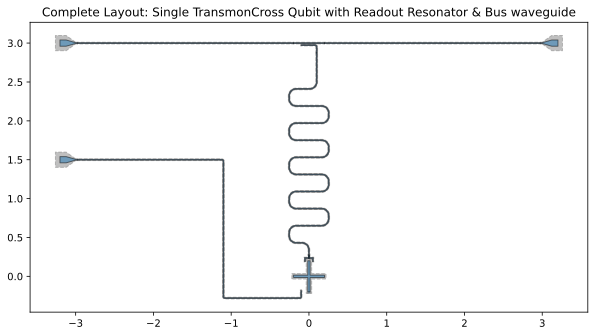

In [33]:
fig, ax = plt.subplots(figsize=(10, 10))
renderer = QMplRenderer(design)
renderer.render(ax)

# Focus plot region
ax.autoscale()
ax.set_aspect('equal')
plt.title("Complete Layout: Single TransmonCross Qubit with Readout Resonator & Bus waveguide")
plt.show()

## 6. Exporting the Design to GDSII

GDSII is the industry standard file format for photomask fabrication. We can use Qiskit Metal's GDS renderer to output the layout geometries to a GDSII file directly.

In [ ]:
# Get GDS renderer from the design renderers list
gds_renderer = design.renderers.gds

# Export the layout
gds_filename = 'single_qubit_resonator_chip.gds'
gds_renderer.export_to_gds(gds_filename)

print(f"Layout exported to GDSII file: {gds_filename}!")

01:34PM 07s WARNING [import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"/Users/mcansarihan/qdw2026/qdw26-workshop-materials/workshops/quantum-device-design/resources".


Layout exported to GDSII file: single_qubit_resonator_chip.gds!


---

## 💬 Stay connected — the Quantum Device Consortium

Workshops are starting points; the community is where the work continues. The single best place to find us — for questions, bugs, design help, or to share what you built — is:

### → [Quantum Device Consortium Discord]({{QDC_DISCORD_INVITE_URL}})

> ⚠️ **Workshop org TODO**: replace `{{QDC_DISCORD_INVITE_URL}}` with a fresh non-expiring Discord invite before publishing.

### More ways to engage — mailing list · GitHub · contribute · maintainers

- 🐛 **Bug reports / feature requests** → [`qiskit-community/qiskit-metal` issues](https://github.com/qiskit-community/qiskit-metal/issues).
- 📬 **QDW + Quantum Device Consortium news + future workshops** → contact `{{QDW_CONTACT_EMAIL}}` to be added to the mailing list. *(Workshop org: fill in.)*
- 🤝 **Contribute** — PRs welcome on `qiskit-metal`, `SQDMetal`, and the broader [ecosystem](https://qiskit-community.github.io/qiskit-metal/ecosystem.html). Easy starting points: tutorial typos, a new [QComponent](https://qiskit-community.github.io/qiskit-metal/tut/2-From-components-to-chip/2.31-Create-a-QComponent-Basic.html), a renderer fix.
- 🧑‍🔧 We're looking for maintainers. Quantum Metal is community-maintained and the surface area is growing. If you'd like to steward a piece, reach out on Discord or to the QDW organising team.
